# Machine Learning
## Supervised Learning - Linear Regression

### Primero importamos las librerias necesarias

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### Cargar el conjunto de datos (Dataset)
Carguemos el dataset y exploremos los datos

In [2]:
file_path = 'Automobile_price_data.csv'
df = pd.read_csv(file_path)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
1,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
2,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
3,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
4,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.8,8.8,101,5800,23,29,16430


### Preparacion de los datos
Necesitamos limpiar los datos para que este preparados para el modelo de regresion.

In [3]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,0.735849,121.132075,98.264151,172.413836,65.607547,53.899371,2461.138365,119.226415,3.300126,3.236352,10.161132,95.836478,5113.836478,26.522013,32.081761,11445.729560
std,1.193086,35.651285,5.167416,11.523177,1.947883,2.268761,481.941321,30.460791,0.267336,0.294888,3.889475,30.718583,465.754864,6.097142,6.459189,5877.856195
min,-2.000000,65.000000,86.600000,141.100000,60.300000,49.400000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,15.000000,18.000000,5118.000000
25%,0.000000,94.000000,94.500000,165.650000,64.000000,52.250000,2065.500000,97.000000,3.050000,3.105000,8.700000,69.000000,4800.000000,23.000000,28.000000,7372.000000
50%,1.000000,113.000000,96.900000,172.400000,65.400000,54.100000,2340.000000,110.000000,3.270000,3.270000,9.000000,88.000000,5200.000000,26.000000,32.000000,9233.000000
75%,2.000000,148.000000,100.800000,177.800000,66.500000,55.500000,2809.500000,135.000000,3.560000,3.410000,9.400000,114.000000,5500.000000,31.000000,37.000000,14719.500000
max,3.000000,256.000000,115.600000,202.600000,71.700000,59.800000,4066.000000,258.000000,3.940000,4.170000,23.000000,200.000000,6600.000000,49.000000,54.000000,35056.000000


In [4]:
# Convert missing values and prepare the dataset
df = df.replace('?', pd.NA).dropna()
df['price'] = pd.to_numeric(df['price'])
df['horsepower'] = pd.to_numeric(df['horsepower'])


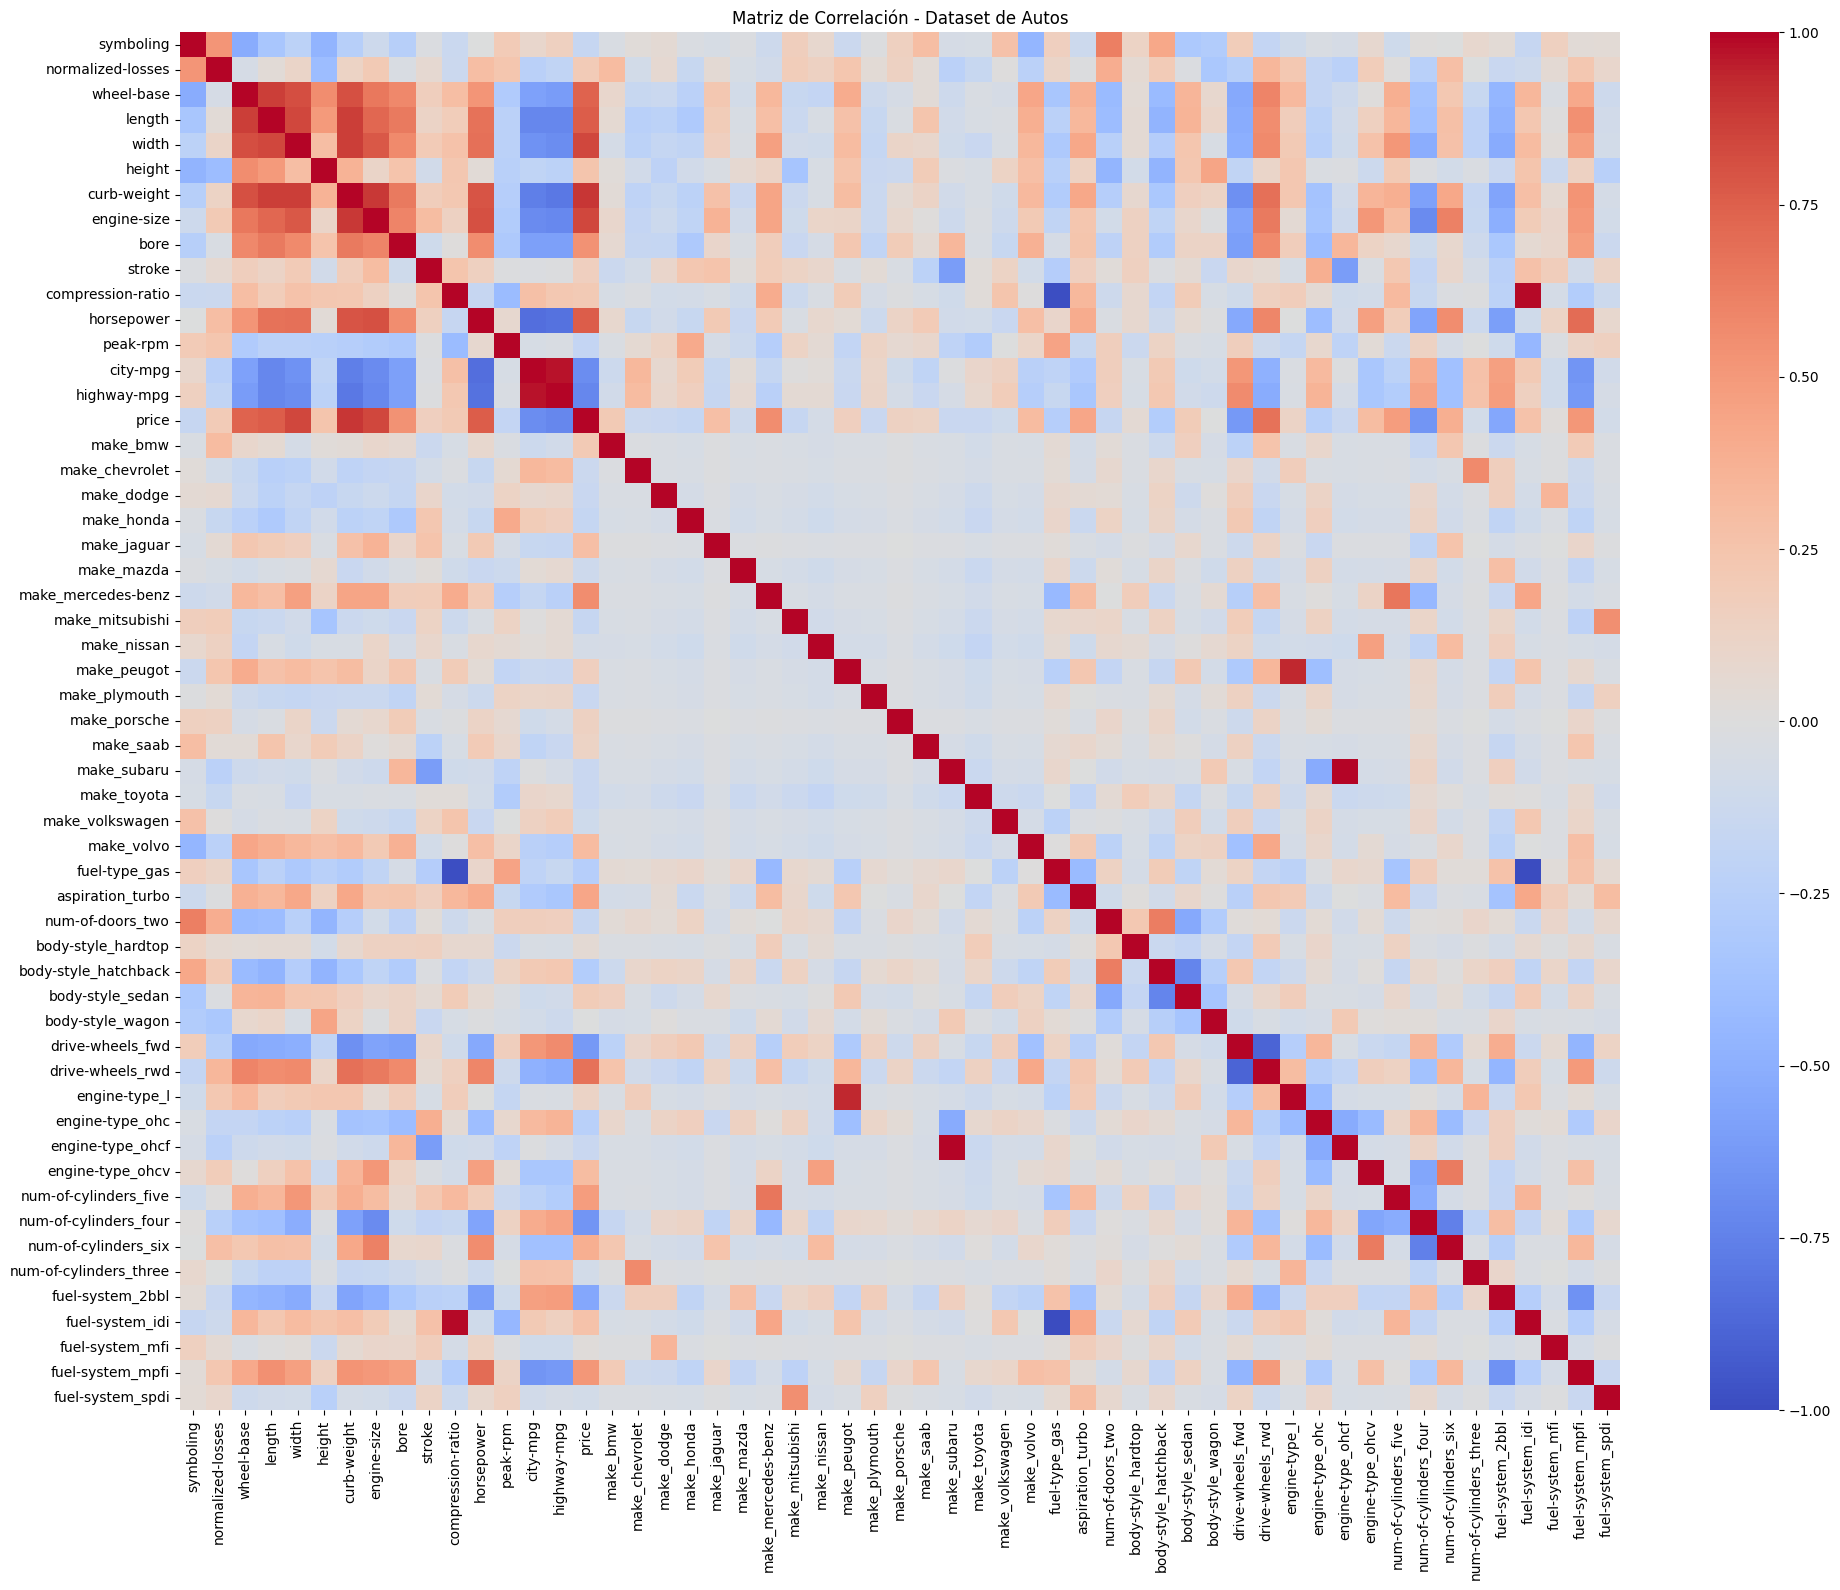


Correlaciones con PRICE (de mayor a menor):
price                 1.000000
curb-weight           0.893639
width                 0.843371
engine-size           0.841496
length                0.760952
horsepower            0.759874
wheel-base            0.734419
drive-wheels_rwd      0.677680
make_mercedes-benz    0.562170
bore                  0.533890
Name: price, dtype: float64

Correlaciones más bajas con PRICE:
make_honda              -0.166074
peak-rpm                -0.171916
engine-type_ohc         -0.244285
fuel-type_gas           -0.261305
body-style_hatchback    -0.280071
fuel-system_2bbl        -0.553336
drive-wheels_fwd        -0.627016
num-of-cylinders_four   -0.649324
city-mpg                -0.692273
highway-mpg             -0.720090
Name: price, dtype: float64


In [5]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_clean = df.dropna()

# 2. Convertir columnas categóricas a numéricas (One-Hot Encoding)
categorical_columns = ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 
                     'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']

df_encoded = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)

# 3. Calcular y mostrar matriz de correlación
plt.figure(figsize=(20, 16))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Dataset de Autos')
plt.tight_layout()
plt.show()

# Opcional: Mostrar correlaciones más fuertes con el precio
if 'price' in df_encoded.columns:
    price_correlations = df_encoded.corr()['price'].sort_values(ascending=False)
    print("\nCorrelaciones con PRICE (de mayor a menor):")
    print(price_correlations.head(10))
    print("\nCorrelaciones más bajas con PRICE:")
    print(price_correlations.tail(10))

In [6]:
# Select features and target variable
# Split the data into features and target variable
X = df_encoded[['horsepower']]
y = df_encoded['price']

### Dividir la informacion
Dividimos la informacion en en datos de entrenamiento y datos de prueba

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Entrenar el modelo
Ahora entrenamois el modelo de regresion linear usando los datos de entrenemiento.

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluar el modelo
Calcularemos el erro promedio al cuadrado (MSE) para evaluar el rendimiento del modelo.

In [9]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R² Score: {r2}')

Mean Squared Error: 7431602.670900866
Root Mean Squared Error: 2726.0965997009107
R² Score: 0.5823682396698118


# Error Cuadrático Medio (RMSE): 2726.10

En promedio, las predicciones del modelo se desvían aproximadamente $2726.10 de los precios reales de los automóviles. 
El RMSE está en las mismas unidades que la variable objetivo (precio), lo que facilita su comprensión.

# Puntaje R²: 0.582

El modelo explica alrededor del 58.2% de la varianza en los precios de los automóviles.
Esto indica un nivel moderado de precisión en las predicciones del modelo.

## Interpretación:

- Las predicciones del modelo son algo precisas, pero se pueden mejorar. La característica de potencia no es suficiente para predecir el precio del automóvil.
- El error promedio de predicción es de aproximadamente $2726.10, lo que es moderado.
- El modelo captura el 58.2% de la variabilidad en los precios de los automóviles, pero aún hay margen para mejorar.

## Próximos Pasos:

- Mejorar el modelo refinando las características y probando diferentes modelos:
  - Usar un **Random Forest Regressor**.
  - Realizar **Regresión Lineal Múltiple** con **Random Forest Regressor**.

- Ajustar la configuración del modelo para reducir los errores.

- Asegurarse de que los datos estén limpios y bien preparados, y manejar cualquier valor atípico o puntos de datos inusuales.



from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Seleccionar las variables predictoras y la variable objetivo
X = df_encoded[['curb-weight', 'width', 'engine-size', 'length', 'horsepower', 'wheel-base', 'drive-wheels_rwd']]
y = df_encoded['price']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Mostrar resultados
print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R² en entrenamiento:", model.score(X_train, y_train))
print("R² en prueba:", model.score(X_test, y_test))

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Seleccionar las variables predictoras y la variable objetivo
X = df_encoded[['curb-weight', 'width', 'engine-size', 'length', 'horsepower', 'wheel-base', 'drive-wheels_rwd']]
y = df_encoded['price']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Mostrar resultados
print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R² en entrenamiento:", model.score(X_train, y_train))
print("R² en prueba:", model.score(X_test, y_test))

Coeficientes: [ 4.25559315e+00  1.11694768e+03  5.23552769e+01 -1.17590082e+02
  7.76275505e-01  9.27329166e+01  2.30316668e+03]
Intercepto: -68143.97046447387
R² en entrenamiento: 0.8671832467023315
R² en prueba: 0.5093066401769364


Interpretación de los resultados:
R² en entrenamiento (0.867):

El modelo explica el 86.7% de la variabilidad del precio con estas variables

Buen ajuste en los datos de entrenamiento

R² en prueba (0.509):

Solo explica el 50.9% en datos nuevos

Problema de overfitting - el modelo se ajustó demasiado a los datos de entrenamiento

Coeficientes:

curb-weight: +4.26 por unidad de peso

width: +1,116.95 por unidad de ancho

engine-size: +52.36 por unidad de tamaño motor

length: -117.59 por unidad de longitud (contraintuitivo)

horsepower: +0.78 por caballo de fuerza

wheel-base: +92.73 por unidad de base

drive-wheels_rwd: +2,303.17 por tracción trasera

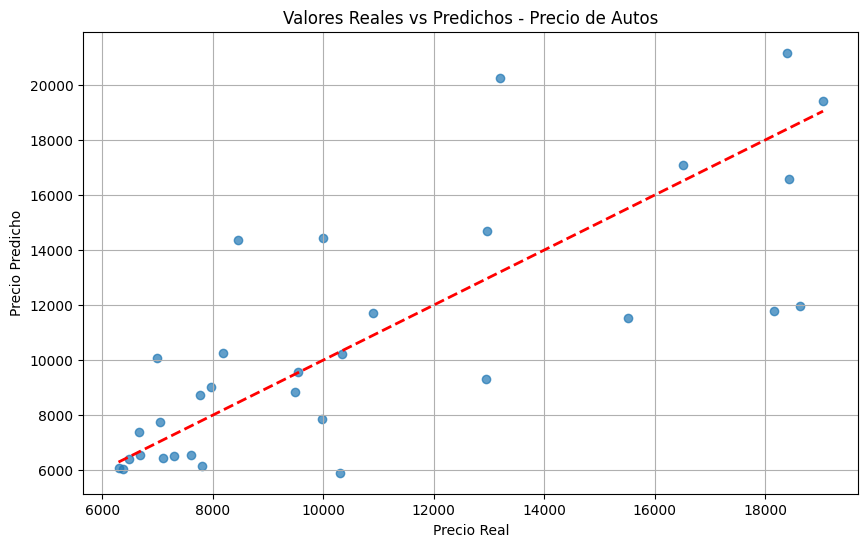

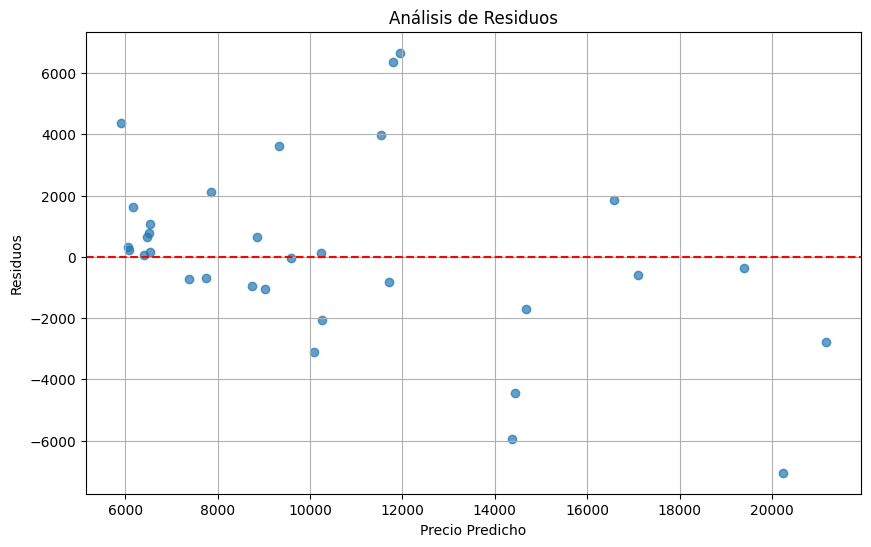

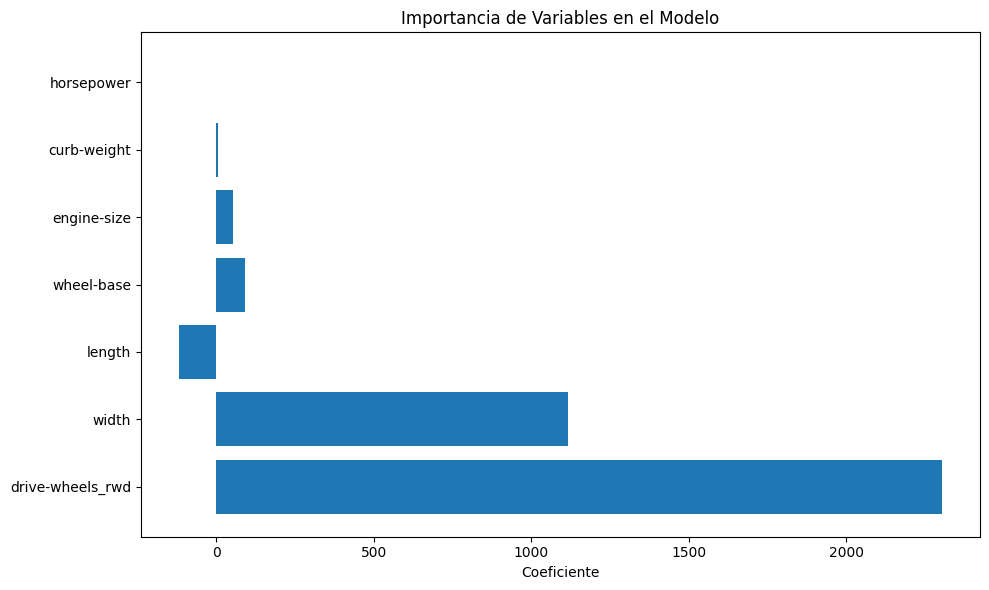


Métricas adicionales:
Error Cuadrático Medio (MSE): 8731706.80
Raíz del Error Cuadrático Medio (RMSE): 2954.95


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Predicciones
y_pred = model.predict(X_test)

# 1. Gráfico de valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Valores Reales vs Predichos - Precio de Autos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Precio Predicho')
plt.ylabel('Residuos')
plt.title('Análisis de Residuos')
plt.grid(True)
plt.show()

# 3. Gráfico de importancia de variables (coeficientes estandarizados)
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Coeficiente'])
plt.xlabel('Coeficiente')
plt.title('Importancia de Variables en el Modelo')
plt.tight_layout()
plt.show()

# Métricas adicionales
print(f"\nMétricas adicionales:")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")